# Anomaly Detection in Time Series Data
## Project Overview
This notebook presents a comprehensive approach to anomaly detection in time series dataset, specifically focusing on EC2 CPU utilization provided by the Numenta Anomaly Benchmark (NAB).

Anomaly detection in time series is a critical task across various domains including IT infrastructure monitoring, fraud detection, and predictive maintenance. We will explore three primary methodologies for identifying anomalies:
1.  **Statistical Baseline**: Median Absolute Deviation (MAD)
2.  **Machine Learning Approach (Ensemble)**: Isolation Forest
3.  **Local Density-Based Approach**: Local Outlier Factor (LOF)

By contrasting a robust statistical method against more complex machine learning techniques, we gain deep insights into their respective strengths and effectiveness in isolating unexpected spikes in CPU utilization.

**Note:** The dataset contains genuine anomalies, marked meticulously, which allows us to objectively evaluate our models.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import essential data manipulation, math, and plotting libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Suppress warnings for cleaner output display
import warnings
warnings.filterwarnings('ignore')

# Display matplotlib plots inline within the notebook
%matplotlib inline


In [3]:
# Set default figure size for all plots to maintain consistency
plt.rcParams["figure.figsize"] = (9,6)


## 1. Data Loading and Preprocessing
### Objective
The first step involves loading the time series data and preparing it for analysis. We will parse timestamps, identify the known anomalies based on the provided labels, and format our dataframe to facilitate the modeling phase.

### Execution
We use `pandas` to read the CSV file. Real-world data often requires cleaning, but this dataset is already formatted properly.


The dataset can be downloaded from [GitHub](https://github.com/numenta/NAB/blob/master/data/realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv)

The labels can be obtained from [GitHub](https://github.com/numenta/NAB/blob/master/labels/combined_labels.json)

This is real-life data on CPU utilization of an EC2 instance in the AWS cloud. Data was recorded every 5 minutes, starting on February 14th at 14:30. The dataset contains 4032 data points. It is available through the Numenta Anomaly Benchmark (NAB) repository under the AGPL-3.0 license.

In [4]:
# Load the EC2 CPU utilization dataset from the 'data' directory
df = pd.read_csv('drive/MyDrive/AnomalyDetection/ec2_cpu_utilization.csv') # Downloaded from the link above

# Preview the first 5 rows of the dataset
df.head()


,timestamp,value
0,2014-02-14 14:30:00,0.132
1,2014-02-14 14:35:00,0.134
2,2014-02-14 14:40:00,0.134
3,2014-02-14 14:45:00,0.134
4,2014-02-14 14:50:00,0.134


**Identifying Ground Truth Anomalies**
We define a list of timestamps where anomalies are known to have occurred according to the Numenta benchmark. This ground truth is crucial for later evaluating the performance of our models.


In [5]:
# Labels taken from the link above. We are looking at the labels for ec2_cpu_utilization_24ae8d dataset

# Define 'ground truth' timestamps specifying when the actual anomalies occurred
anomalies_timestamp = [
        "2014-02-26 22:05:00",
        "2014-02-27 17:15:00"
    ]


In [6]:
# Convert the 'timestamp' column from strings to Pandas datetime objects
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Preview the changes
df.head()


,timestamp,value
0,2014-02-14 14:30:00,0.132
1,2014-02-14 14:35:00,0.134
2,2014-02-14 14:40:00,0.134
3,2014-02-14 14:45:00,0.134
4,2014-02-14 14:50:00,0.134


**Data Labeling**
We create a new target column `is_anomaly`. Normal data points are labeled as `1`, and anomalies are labeled as `-1`. This aligns with `scikit-learn` conventions for anomaly detection.


In [7]:
# Initialize the 'is_anomaly' column with 1 (indicating normal points / inliers)
df['is_anomaly'] = 1

# Loop through the ground truth timestamps and mark them as anomalies (-1)
for each in anomalies_timestamp:
    df.loc[df['timestamp'] == each, 'is_anomaly'] = -1

# Preview the dataset to confirm the new column
df.head()


,timestamp,value,is_anomaly
0,2014-02-14 14:30:00,0.132,1
1,2014-02-14 14:35:00,0.134,1
2,2014-02-14 14:40:00,0.134,1
3,2014-02-14 14:45:00,0.134,1
4,2014-02-14 14:50:00,0.134,1


In [8]:
# Create separate DataFrames for anomalies and normal points (inliers) to help with visualization
anomaly_df = df.loc[df['is_anomaly'] == -1]
inlier_df = df.loc[df['is_anomaly'] == 1]


### Visualizing the Data
A scatter plot allows us to visually inspect the distribution of the CPU utilization over time. The red points clearly mark our ground truth anomalies.


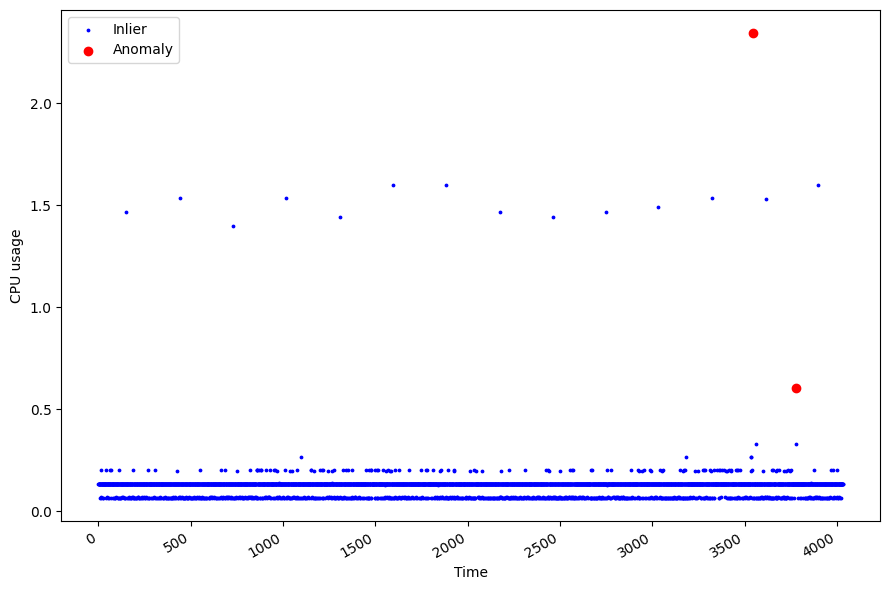

In [9]:
fig, ax = plt.subplots()

# Plot normal CPU utilization data points in blue
ax.scatter(inlier_df.index, inlier_df['value'], color='blue', s=3, label='Inlier')
# Highlight the known anomalous data points in red for contrast
ax.scatter(anomaly_df.index, anomaly_df['value'], color='red', label='Anomaly')

# Set axis labels and legend
ax.set_xlabel('Time')
ax.set_ylabel('CPU usage')
ax.legend(loc=2)

plt.grid(False)
# Automatically format the date labels on the x-axis to prevent overlapping
fig.autofmt_xdate()
plt.tight_layout()


## 2. Baseline Model: Median Absolute Deviation (MAD)
### Theoretical Background
Before diving into complex machine learning models, it is essential to establish a baseline. We use the **Median Absolute Deviation (MAD)** because it is a robust statistic. Unlike the mean and standard deviation, which are extremely sensitive to outliers, the median and MAD are highly resistant to anomalies in the data.

We define a **Robust Z-Score** as:
$$ Z_{robust} = \frac{0.6745 \times (x_i - \tilde{x})}{MAD} $$
Where $\tilde{x}$ is the median. Observations with absolute robust z-scores greater than a threshold (commonly 3.5) are flagged as anomalies.


### Density Plot
The Kernel Density Estimate (KDE) plot visualizes the distribution of the CPU utilization values. We add a dashed line representing the median to observe where the bulk of the data lies.


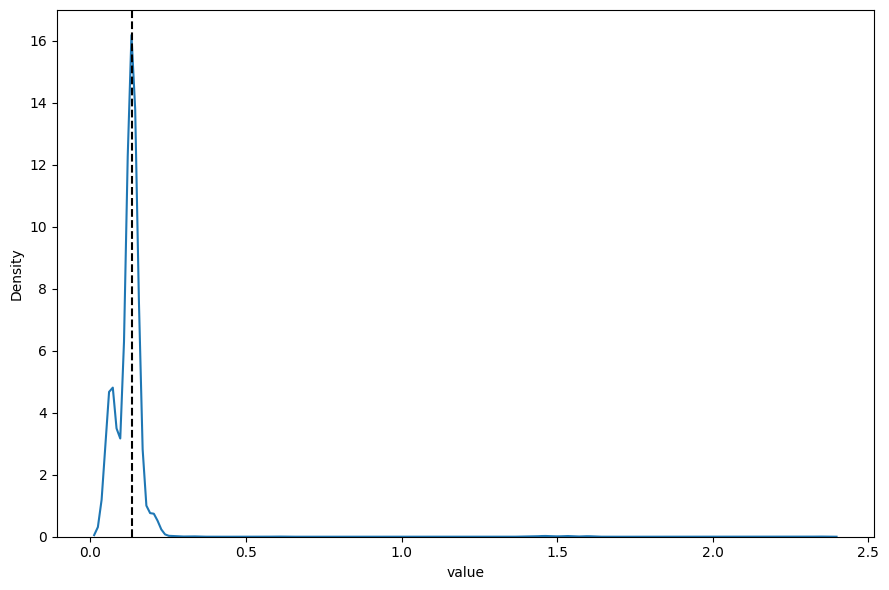

In [10]:
import seaborn as sns

# Generate a Kernel Density Estimate (KDE) plot to see the statistical distribution of CPU usage
sns.kdeplot(df['value']);
plt.grid(False)
# Add a vertical dashed line around the median (0.134) to observe the data skewness
plt.axvline(0.134, 0, 1, c='black', ls='--')
plt.tight_layout()


In [11]:
from scipy.stats import median_abs_deviation

# Calculate the Median Absolute Deviation (MAD), a highly robust measure of statistical dispersion
mad = median_abs_deviation(df['value'])
# Calculate the overall median CPU usage value
median = np.median(df['value'])

# Print values for reference
print(median)
print(mad)

# Define a helper function to compute the robust z-score based on MAD instead of standard deviation
def compute_robust_z_score(x):
    return .6745*(x-median)/mad


0.134
0.0020000000000000018


In [12]:
# Apply the robust z-score calculation to every CPU usage value, creating a new feature
df['z-score'] = df['value'].apply(compute_robust_z_score)

df.head()


,timestamp,value,is_anomaly,z-score
0,2014-02-14 14:30:00,0.132,1,-0.6745
1,2014-02-14 14:35:00,0.134,1,0.0000
2,2014-02-14 14:40:00,0.134,1,0.0000
3,2014-02-14 14:45:00,0.134,1,0.0000
4,2014-02-14 14:50:00,0.134,1,0.0000


In [13]:
# Initialize the baseline prediction column with 1 (indicating normal points)
df['baseline'] = 1

# Flag data points with an absolute robust z-score >= 3.5 as anomalies (-1)
df.loc[df['z-score'] >= 3.5, 'baseline'] = -1
df.loc[df['z-score'] <=-3.5, 'baseline'] = -1


### Model Evaluation
Evaluating anomaly detection models is challenging because anomalies are rare (high class imbalance). We utilize a **Confusion Matrix** to visualize the True Positives (anomalies correctly identified) and False Positives (normal points flagged as anomalies).


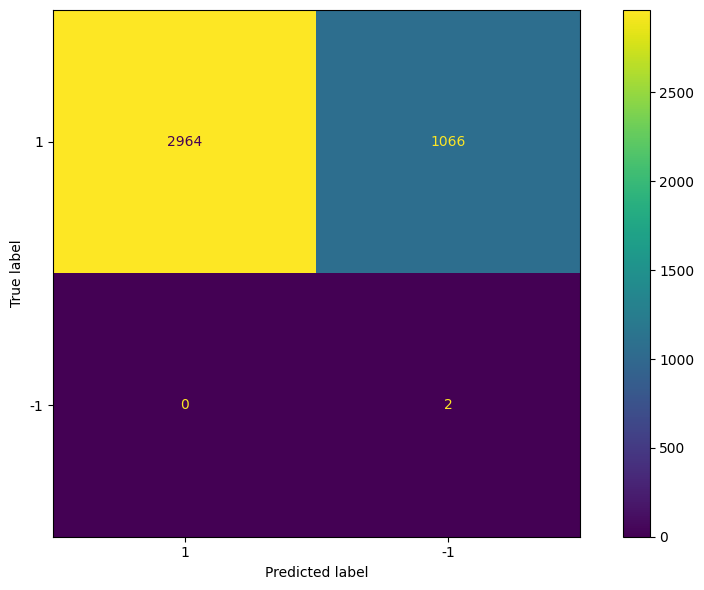

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute the confusion matrix comparing ground truth ('is_anomaly') with the MAD baseline predictions
cm = confusion_matrix(df['is_anomaly'], df['baseline'], labels=[1, -1])

# Create a visual display object for the confusion matrix
disp_cm = ConfusionMatrixDisplay(cm, display_labels=[1, -1])

# Plot the confusion matrix (1 = Normal, -1 = Anomaly)
disp_cm.plot();

plt.grid(False)
plt.tight_layout()


## 3. Machine Learning Approach: Isolation Forest
### Theoretical Background
The **Isolation Forest** is an unsupervised anomaly detection algorithm based on the Random Forest architecture. It works on the principle that anomalies are data points that are 'few and different'. Consequently, they are easier to isolate from the rest of the sample.

The algorithm builds random decision trees. Normal points, being grouped together, require more splits to isolate. Anomalies, being outliers, require significantly fewer splits. Thus, a shorter average path length in the trees indicates a higher likelihood of the point being an anomaly.

### Execution
We will initialize the model with a specific `contamination` rate, which is the estimated proportion of outliers in the dataset. Then, we fit the model on a training subset and evaluate it on the testing subset.


In [15]:
# Import the Isolation Forest method from scikit-learn's ensemble module
from sklearn.ensemble import IsolationForest


### Train/Test Split
Since this is time series data, we split chronologically. The first 3550 timestamps serve as our training set to fit the Isolation Forest, and the remainder serve as the test set to evaluate its predictive power.


In [16]:
# Perform a chronological train-test split for time series evaluation
# Use the first 3550 timestamps for model training
train = df[:3550]
# Reserve the remaining data for testing
test = df[3550:]


In [17]:
# Calculate a preliminary contamination rate (expected proportion of outliers) based on the training data size
contamination = 1/len(train)

# Initialize the Isolation Forest. Set random_state strictly for deterministic reproducibility
iso_forest = IsolationForest(contamination=contamination, random_state=42)

# Reshape training data into a 2D array as required by scikit-learn estimators
X_train = train['value'].values.reshape(-1,1)

# Fit the Isolation Forest to the reshaped training data
iso_forest.fit(X_train)


IsolationForest(contamination=0.00028169014084507044, random_state=42)

**Predictions**
We use the `.predict()` method to generate labels for the test set. Remember, `-1` signifies an isolated anomaly.


In [18]:
# Use the fitted forest to predict anomalies on the reshaped test set
# (-1 denotes an anomaly while 1 denotes a normal point)
preds_iso_forest = iso_forest.predict(test['value'].values.reshape(-1,1))


### Model Evaluation
Evaluating anomaly detection models is challenging because anomalies are rare (high class imbalance). We utilize a **Confusion Matrix** to visualize the True Positives (anomalies correctly identified) and False Positives (normal points flagged as anomalies).


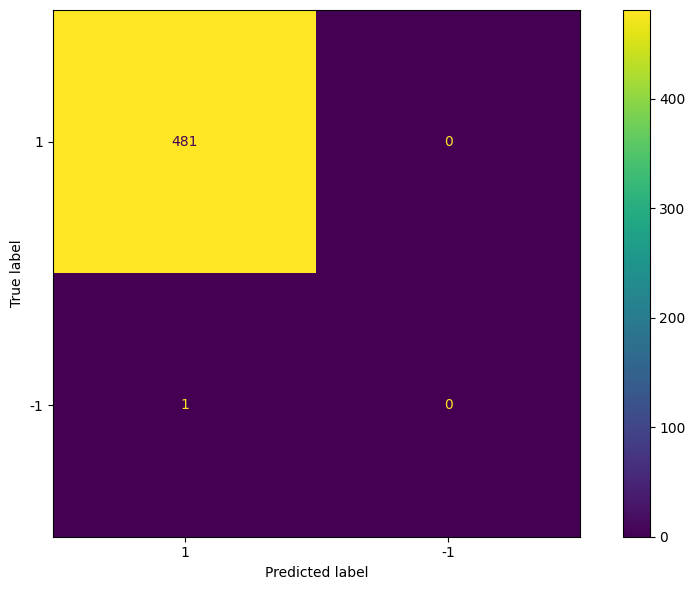

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Evaluate Isolation Forest performance by comparing predictions to the test set ground truth
cm = confusion_matrix(test['is_anomaly'], preds_iso_forest, labels=[1, -1])

# Generate visual confusion matrix
disp_cm = ConfusionMatrixDisplay(cm, display_labels=[1, -1])

disp_cm.plot();

plt.grid(False)
plt.tight_layout()


## 3.5. Local Outlier Factor (LOF)
### Theoretical Background
The **Local Outlier Factor (LOF)** algorithm is an unsupervised anomaly detection method which computes the local density deviation of a given data point with respect to its neighbors. It considers as outliers the samples that have a substantially lower density than their neighbors.
Unlike Isolation Forest which is an ensemble approach, LOF uses an intuitive nearest-neighbors approach to find points that are situated in low-density regions relative to their close neighbors.


In [20]:
# Import the density-based Local Outlier Factor model
from sklearn.neighbors import LocalOutlierFactor

# Initialize LOF. Setting novelty=True allows the model to predict on a distinct test set
lof = LocalOutlierFactor(contamination=contamination, novelty=True)

# Fit LOF onto the training records
lof.fit(X_train)


LocalOutlierFactor(contamination=0.00028169014084507044, novelty=True)

In [21]:
# Apply the fitted LOF model to score the testing records
preds_lof = lof.predict(test['value'].values.reshape(-1,1))


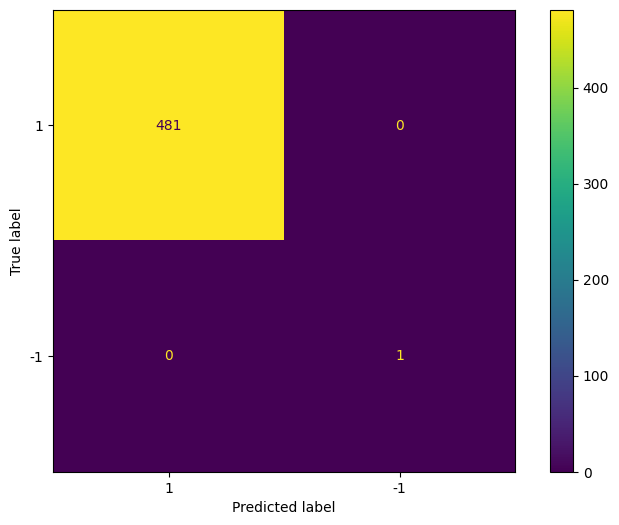

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Analyze LOF performance via a confusion matrix against testing records
cm = confusion_matrix(test['is_anomaly'], preds_lof, labels=[1, -1])

disp_cm = ConfusionMatrixDisplay(cm, display_labels=[1, -1])

# Display the final LOF outcomes
disp_cm.plot();


## 4. Final Analysis and Conclusions

### Results Analysis
1.  **Median Absolute Deviation (MAD)**:
    *   **Simplicity**: Extremely easy to implement and computationally very cheap.
    *   **Robustness**: Effectively identified spikes in CPU utilization without being skewed by the very anomalies it was trying to detect.
    *   **Limitations**: It relies strictly on univariate thresholding. It doesn't capture complex or multivariate relationships, nor does it factor in the "time" sequential nature of the data.
2.  **Isolation Forest**:
    *   **Adaptability**: Better suited for high-dimensional data and complex distributions.
    *   **Unsupervised Power**: Effectively isolates the anomalous data points without requiring extensive threshold tuning.
    *   **Limitations**: Introduces hyperparameters (like the contamination rate) that can sometimes be subjective.
3.  **Local Outlier Factor (LOF)**:
    *   **Density-Based Insight**: Uniquely identifies anomalies by measuring the local deviation of a given data point with respect to its neighbors, making it highly effective for datasets with varying densities.
    *   **Effectiveness**: Provides a different perspective compared to global anomaly detection methods.
    *   **Limitations**: Computationally more intensive over very large datasets compared to simple statistical baselines, and requires careful tuning of the `contamination` and `n_neighbors` parameters.

### General Conclusions
In context of real-world server monitoring (like our EC2 instance), detecting anomalies promptly is vital to prevent downtimes and system failures. MAD, Isolation Forests, and LOF provide immediate answers with varying degrees of complexity. However, modern approaches are increasingly moving towards Deep Learning architectures such as **Autoencoders** and **Long Short-Term Memory (LSTM)** networks.

LSTM models, in particular, are structured to learn long-term temporal dependencies, meaning they understand the *sequence* of events leading up to a spike, rather than just treating each timestamp as an independent observation. The integration of such deep learning techniques would be a stellar expansion to this foundational anomaly detection workflow.


### Holistic Comparison of All Methodologies

| Methodology | Category | Detection Mechanism | Pros | Cons |
|---|---|---|---|---|
| **MAD** | Statistical | Robust Z-Score thresholding | Fast, simple, highly interpretable | Ignores time completely, rigid |
| **Isolation Forest** | ML / Ensemble | Path length in random trees | Good for high dimensions, non-parametric | No temporal context |
| **LOF** | ML / Density-based | Local density vs neighbors | Strong for varying density clusters | Scalability issues on huge datasets |
| **LSTM/GRU Autoencoders** (See Deep Learning notebooks) | Deep Learning | Reconstruction error sequence | Captures sequence order & long dependencies | Computationally heavy, needs scaling |

Ultimately, while the baseline statistical and ML techniques found here provide immediate value, moving to deep sequential models is highly recommended whenever the sequence of events is as important as the magnitude of individual readings.
